In [1]:
# Import Libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Load and Preprocess Dataset

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_directory(
    "dataset/training_set",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary"
)

test_set = test_datagen.flow_from_directory(
    "dataset/test_set",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary"
)

Found 8005 images belonging to 1 classes.
Found 2023 images belonging to 1 classes.


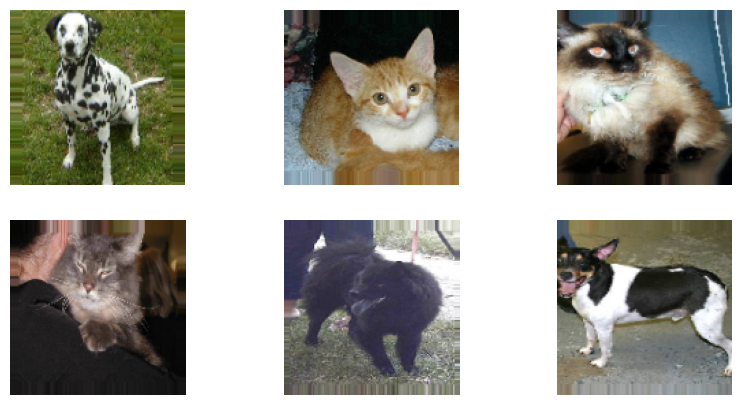

In [3]:
# Visualize Sample Images

images, labels = next(train_set)

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [6]:
# Build CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile Model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
# Train Model

history = model.fit(
    train_set,
    validation_data=test_set,
    epochs=10
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - accuracy: 0.9981 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 5.5108e-35
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 156s 619ms/step - accuracy: 1.0000 - loss: 4.8529e-25 - val_accuracy: 1.0000 - val_loss: 5.5108e-35
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 148s 590ms/step - accuracy: 1.0000 - loss: 9.3184e-26 - val_accuracy: 1.0000 - val_loss: 5.5108e-35
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 148s 587ms/step - accuracy: 1.0000 - loss: 6.4603e-21 - val_accuracy: 1.0000 - val_loss: 5.5108e-35
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 597ms/step - accuracy: 1.0000 - loss: 1.5300e-23 - val_accuracy: 1.0000 - val_loss: 5.5108e-35
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 151s 601ms/step - accuracy: 1.0000 - loss: 2.1987e-22 - val_accuracy: 1.0000 - val_loss: 5.5108e-35
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 148s 590ms/step - accuracy: 1.0000 - loss: 6.6139e-23 - val_accuracy: 1.0000 - val_loss: 5.5108e-35
Epoch 8/10
251/251 ━━━━━━━━

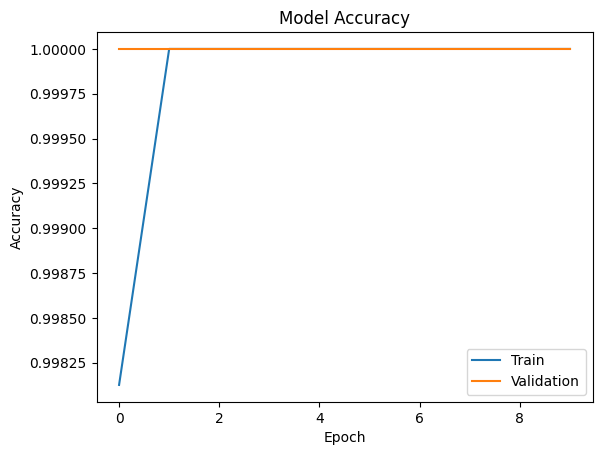

In [9]:
# Accuracy Graph

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])
plt.show()

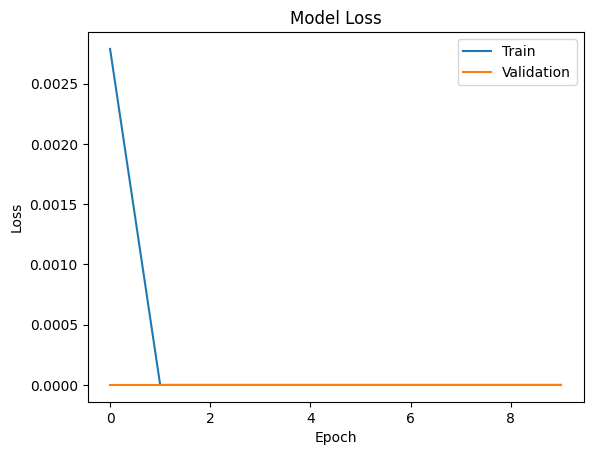

In [10]:
# Loss Graph

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])
plt.show()

In [11]:
# Evaluate Model

loss, accuracy = model.evaluate(test_set)

print("Test Accuracy:", accuracy)

64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 1.0000 - loss: 5.5108e-35
Test Accuracy: 1.0


In [12]:
# Save Model

model.save("cnn_cat_dog_model.keras")

In [17]:
# Predict New Image

from tensorflow.keras.preprocessing import image

img = image.load_img(
    "dog.webp",
    target_size=(128,128)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array/255

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Cat")
else:
    print("Dog")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Dog
